In [1]:
import sys
import os
import pandas as pd

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
%load_ext autoreload
%autoreload 2
pjoin = os.path.join

In [2]:
from hep_rewgt_tk.reweight_app import SingleXGBReweighter
from hep_rewgt_tk.reweight_nn import SingleMLPRwgter
from hep_rewgt_tk.reweight_adversarial import AdversarialReweighter
from src.plotting.visutil import CSVPlotter

## Pre-clean datasets

In [3]:
# define data and results directory, load data
ABCD_dir = "/Users/yuntongzhou/Desktop/Dihiggszztt/output/ABCD"
plot_dir = "/Users/yuntongzhou/Desktop/Dihiggszztt/output/plots/ABCD_ttOnly"
results_dir = "/Users/yuntongzhou/Desktop/Dihiggszztt/output"
Res1b_SS = pd.read_csv(f'{ABCD_dir}/Res1b_SS.csv', index_col=0)
Res1b_OS = pd.read_csv(f'{ABCD_dir}/Res1b_OS.csv', index_col=0)
Res2b_SS = pd.read_csv(f'{ABCD_dir}/Res2b_SS.csv', index_col=0)
Res2b_OS = pd.read_csv(f'{ABCD_dir}/Res2b_OS.csv', index_col=0)

def apply_all(dfs, func):
    filtered = [None] * len(dfs)
    for i, df in enumerate(dfs):
        filtered[i] = func(df.copy())
    return filtered

def keep_fake_ttbar(df):
    df = df[df.group=='TTbar']
    cond_1 = df['LDTau_genflav'] < 5
    cond_2 = df['SDTau_genflav'] < 5 
    return df[((cond_1) | (cond_2))]

def keep_real_ttbar(df):
    df = df[df.group=='TTbar']
    cond_1 = df['LDTau_genflav'] >= 5
    cond_2 = df['SDTau_genflav'] >= 5 
    return df[((cond_1) | (cond_2))]

def signal_id_level(df):
    mask_1 = df['LDTau_idvsjet'] >= 1 # VVV loose WP
    mask_2 = df['SDTau_idvsjet'] >= 1 # VVV loose WP
    mask_3 = df['LDTau_idvse'] >= 3 # VLoose
    mask_4 = df['SDTau_idvse'] >= 3 # VLoose
    mask_5 = df['LDTau_idvsmu'] >= 4 # Tight
    mask_6 = df['SDTau_idvsmu'] >= 4 # Tight
    return df[(mask_1) & (mask_2) & (mask_3) & (mask_4) & (mask_5) & (mask_6)]

In [4]:
df_2b = keep_fake_ttbar(
    signal_id_level(pd.concat([Res2b_SS, Res2b_OS], ignore_index=True, axis=0)))
df_1b = keep_fake_ttbar(
    signal_id_level(pd.concat([Res1b_SS, Res1b_OS], ignore_index=True, axis=0)))

In [5]:
from src.utils.mathutil import ABCDUtil
from src.utils.plotutil import PlotUtil
print("1 b-tagged channel =====================================")
ABCDUtil.pearson_corr(df_1b, 'OS', 'DiJet_mass')
print("\n \n2 b-tagged channel =====================================")
ABCDUtil.pearson_corr(df_2b, 'OS', 'DiJet_mass')

1 b-tagged channel =====================================
Pearson Correlation Coefficient: -0.008170265840340647
P-value: 2.229073602654922e-05

 
2 b-tagged channel =====================================
Pearson Correlation Coefficient: 0.00113652655742894
P-value: 0.5475925737617081


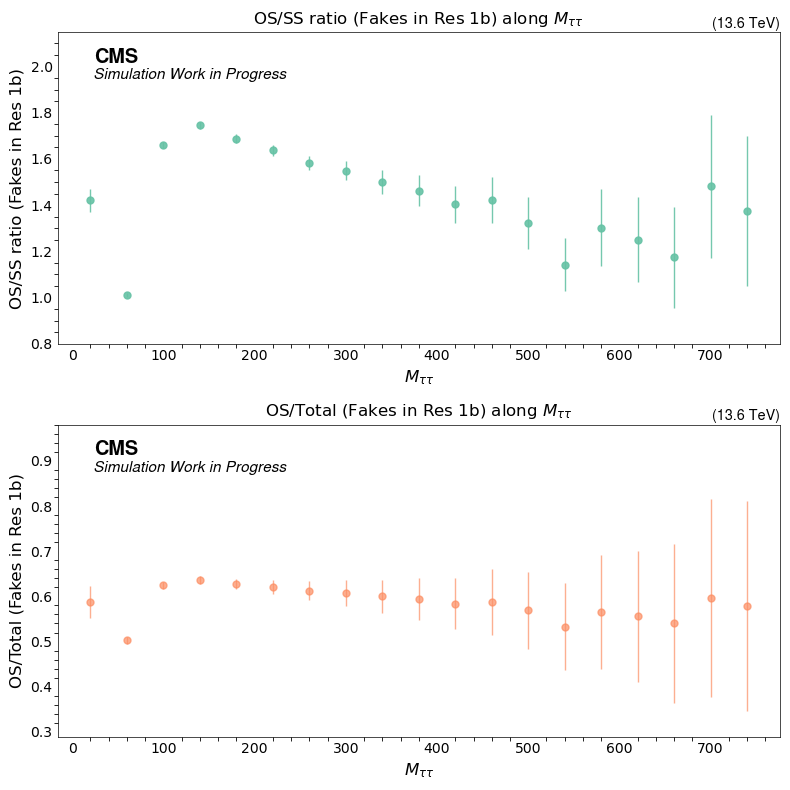

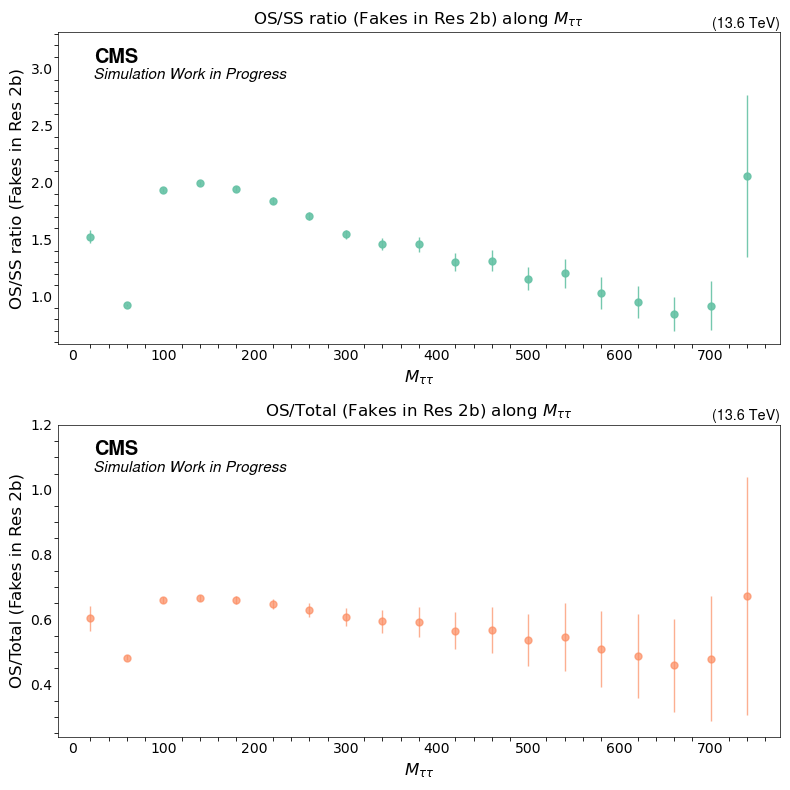

In [6]:
# Plot Correlations
PlotUtil.corr_discrete(df_1b, 'OS', 'DiTau_mass', r'$M_{\tau \tau}$', 'OS/SS ratio (Fakes in Res 1b)', 'OS/Total (Fakes in Res 1b)', f'{plot_dir}/OSRatio_DiTauM_1b.png', 20, (0, 800), 'weight')
PlotUtil.corr_discrete(df_2b, 'OS', 'DiTau_mass', r'$M_{\tau \tau}$', 'OS/SS ratio (Fakes in Res 2b)', 'OS/Total (Fakes in Res 2b)', f'{plot_dir}/OSRatio_DiTauM_2b.png', 20, (0, 800), 'weight')

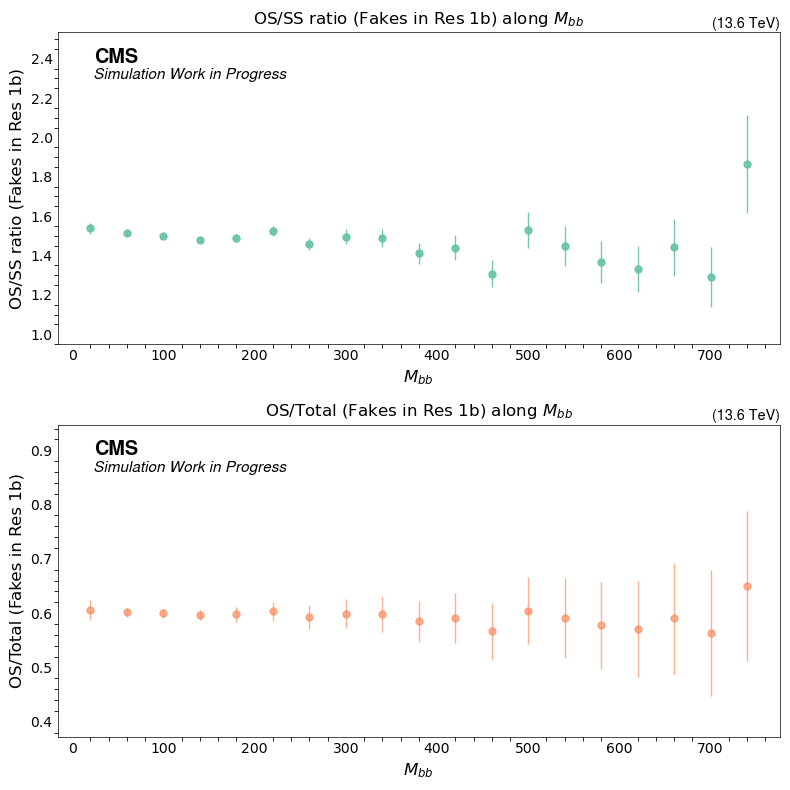

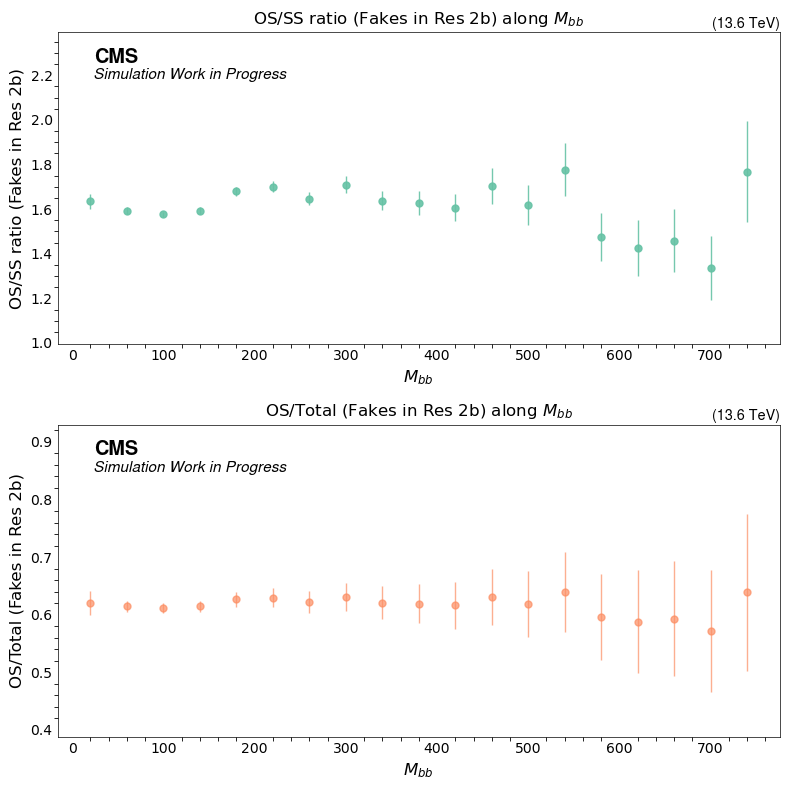

In [7]:
PlotUtil.corr_discrete(df_1b, 'OS', 'DiJet_mass', r'$M_{bb}$', 'OS/SS ratio (Fakes in Res 1b)', 'OS/Total (Fakes in Res 1b)', f'{plot_dir}/OSRatio_DiJetM_1b.png', 20, (0, 800), 'weight')
PlotUtil.corr_discrete(df_2b, 'OS', 'DiJet_mass', r'$M_{bb}$', 'OS/SS ratio (Fakes in Res 2b)', 'OS/Total (Fakes in Res 2b)', f'{plot_dir}/OSRatio_DiJetM_2b.png', 20, (0, 800), 'weight')

In [6]:
# further split the data into training and testing based on mass
def split_mass(df_ori):
    df = df_ori.copy()[(df_ori['DiJet_mass'] > 90)]
    condition = df['DiJet_mass'] > 160
    train = df[condition]
    test = df[~condition]
    return train, test

def split_sign(df_ori):
    df = df_ori.copy()
    condition = df['OS'] == False
    ss = df[condition]
    os = df[~condition]
    return ss, os

def get_train_test(df_ori):
    train_df, val_df = split_mass(df_ori)
    ss_df, os_df = split_sign(train_df)
    val_ss_df, val_os_df = split_sign(val_df)
    return ss_df, os_df, val_ss_df, val_os_df

ss_1b, os_1b, val_ss_1b, val_os_1b = get_train_test(df_1b)
ss_2b, os_2b, val_ss_2b, val_os_2b = get_train_test(df_2b)
ABCD_Helper = ABCDUtil(val_os_1b, os_1b, val_ss_1b, ss_1b, 'weight')
print("Getting ABCD closure stats for 1b channel")
ABCD_Helper.get_all_stats()
ABCD_Helper = ABCDUtil(val_os_2b, os_2b, val_ss_2b, ss_2b, 'weight')
print("\n \n Getting ABCD closure stats for 2b channel")
ABCD_Helper.get_all_stats()

Getting ABCD closure stats for 1b channel
          Events (Raw)  Events (Weighted)
Region                                   
Region A         60239               5047
Region B         41572               3416
Region C         40004               3496
Region D         28272               2417
The closure stats for Events: 
                                    Raw       Weighted
Metric                                                
Predicted events in A    58823 ± 540.48  4940 ± 155.62
Prediction/Actual ratio           0.976          0.979
Pull significance                 4.104          1.074
Deviation                         2.620          0.690
Percentage difference              2.4%           2.1%

 
 Getting ABCD closure stats for 2b channel
          Events (Raw)  Events (Weighted)
Region                                   
Region A         62237               5199
Region B         63996               5206
Region C         36923               3287
Region D         36064            

In [7]:
drop_kwds = ['Gen', 'weight_values', 'Weight_values', 'OS', 'group', 'gen', 'dataset', 'label', 'id', 'year', 'Tau_charge', 'X_num']

In [123]:
mlp_rwgter = SingleMLPRwgter(ss_1b, os_1b, 'weight', results_dir)
mlp_rwgter.prep_data(drop_kwds)
shallow_args= {
    'num_epochs': 100,
    'hidden_arch': 'high_dim',
    'batch_size': 256,
    'lr': 0.001,
    'save': True,
    'savename': 'basic_model.pth',
    'save_interval': 30}
mlp_rwgter.train(**shallow_args)

Dropped  179  events with negative weights out of  28272  events.
Dropped  270  events with negative weights out of  41572  events.
Features: ['LDTau_pt', 'LDTau_eta', 'LDTau_phi', 'LDTau_mass', 'LDTau_dxy', 'LDTau_dz', 'SDTau_pt', 'SDTau_eta', 'SDTau_phi', 'SDTau_mass', 'SDTau_dxy', 'SDTau_dz', 'LDBjet_pt', 'LDBjet_eta', 'LDBjet_phi', 'LDBjet_mass', 'LDBjet_btag', 'SDBjet_pt', 'SDBjet_eta', 'SDBjet_phi', 'SDBjet_mass', 'SDBjet_btag', 'DiTau_pt', 'DiTau_eta', 'DiTau_phi', 'DiTau_mass', 'DiJet_pt', 'DiJet_eta', 'DiJet_phi', 'DiJet_mass', 'Tau_dR', 'Bjet_dR', 'RecoH_dR', 'HT', 'LDTau_px', 'LDTau_py', 'LDTau_pz', 'SDTau_px', 'SDTau_py', 'SDTau_pz', 'LDBjet_px', 'LDBjet_py', 'LDBjet_pz', 'SDBjet_px', 'SDBjet_py', 'SDBjet_pz', 'DiTau_px', 'DiTau_py', 'DiTau_pz', 'DiJet_px', 'DiJet_py', 'DiJet_pz']
Epoch 1/100, Train Loss: 0.0579, Val Loss: 0.0569
Epoch 11/100, Train Loss: 0.0568, Val Loss: 0.0566
Epoch 21/100, Train Loss: 0.0566, Val Loss: 0.0564
Model saved at /Users/yuntongzhou/Desktop/Di

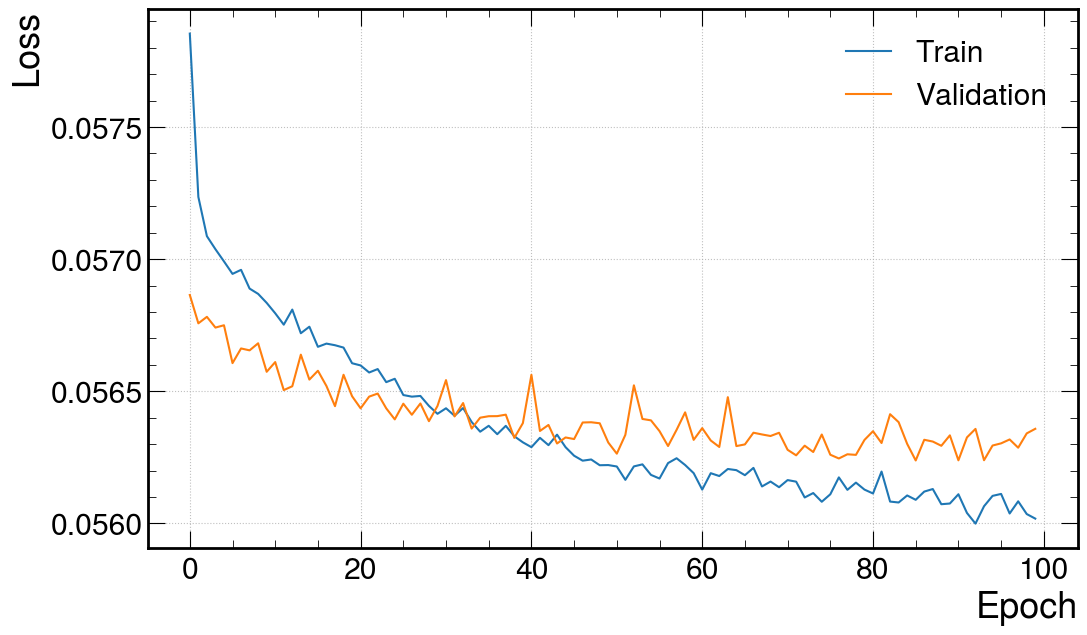

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/yuntongzhou/miniconda3/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3526, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/w4/tl7q52611yg4x42kkpb7bm0m0000gn/T/ipykernel_69952/2519054548.py", line 2, in <module>
    mlp_rwgter.visualize()
  File "/Users/yuntongzhou/Desktop/Dihiggszztt/HEPReWgtTK/hep_rewgt_tk/reweight_nn.py", line 167, in visualize
    self.model.visualize_architecture_hl(save_path=pjoin(os.path.abspath(self.results_dir), 'model_architecture.png'))
  File "/Users/yuntongzhou/Desktop/Dihiggszztt/HEPReWgtTK/hep_rewgt_tk/reweight_base.py", line 528, in visualize_architecture_hl
    graph = hl.build_graph(self.model,
  File "/Users/yuntongzhou/miniconda3/lib/python3.10/site-packages/hiddenlayer/graph.py", line 143, in build_graph
    import_graph(g, model, args)
  File "/Users/yuntongzhou/miniconda3/lib/python3.10/site-packages/hiddenlayer/pytorch_builder.py", line

In [152]:
#mlp_rwgter.load_checkpoint(pjoin(results_dir,'basic_model_90.pth'), input_dim = len(mlp_rwgter.features), hidden_choice='high_dim')
mlp_rwgter.visualize()
# ss_1b_rwgt = mlp_rwgter.reweight(ss_1b, os_1b.weight.sum(), drop_kwds, True, 'mlp_rewgt_1b_train')
# val_ss_1b_rwgt = mlp_rwgter.reweight(val_ss_1b, os_1b.weight.sum(), drop_kwds, True, 'mlp_rewgt_1b_val')

Dropped  277  events with negative weights out of  36064  events.
Dropped  466  events with negative weights out of  63996  events.
Features: ['LDTau_pt', 'LDTau_eta', 'LDTau_phi', 'LDTau_mass', 'LDTau_dxy', 'LDTau_dz', 'SDTau_pt', 'SDTau_eta', 'SDTau_phi', 'SDTau_mass', 'SDTau_dxy', 'SDTau_dz', 'LDBjet_pt', 'LDBjet_eta', 'LDBjet_phi', 'LDBjet_mass', 'LDBjet_btag', 'SDBjet_pt', 'SDBjet_eta', 'SDBjet_phi', 'SDBjet_mass', 'SDBjet_btag', 'DiTau_pt', 'DiTau_eta', 'DiTau_phi', 'DiTau_mass', 'DiJet_pt', 'DiJet_eta', 'DiJet_phi', 'DiJet_mass', 'Tau_dR', 'Bjet_dR', 'RecoH_dR', 'HT', 'LDTau_px', 'LDTau_py', 'LDTau_pz', 'SDTau_px', 'SDTau_py', 'SDTau_pz', 'LDBjet_px', 'LDBjet_py', 'LDBjet_pz', 'SDBjet_px', 'SDBjet_py', 'SDBjet_pz', 'DiTau_px', 'DiTau_py', 'DiTau_pz', 'DiJet_px', 'DiJet_py', 'DiJet_pz']
Epoch 1/120, Train Loss: 0.0558, Val Loss: 0.0542
Epoch 11/120, Train Loss: 0.0538, Val Loss: 0.0538
Epoch 21/120, Train Loss: 0.0537, Val Loss: 0.0538
Model saved at /Users/yuntongzhou/Desktop/Di

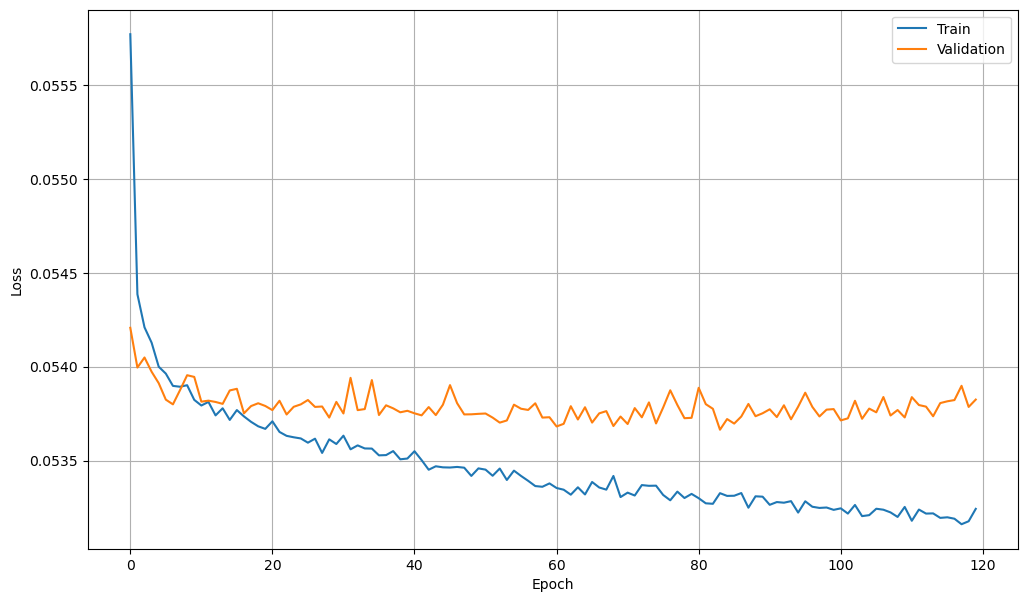

In [8]:
mlp_rwgter = SingleMLPRwgter(ss_2b, os_2b, 'weight', results_dir)
mlp_rwgter.prep_data(drop_kwds)
shallow_args= {
    'num_epochs': 120,
    'hidden_arch': 'high_dim',
    'batch_size': 256,
    'lr': 0.001,
    'save': True,
    'savename': 'deep_2b.pth',
    'save_interval': 30}
mlp_rwgter.train(**shallow_args)
mlp_rwgter.visualize()

In [128]:
src_df, tar_df = split_sign(df_1b)
total_1b_rwgt = mlp_rwgter.reweight(src_df, tar_df.weight.sum(), drop_kwds, True, 'mlp_rewgt_1b_total')

Dropped  473  events with negative weights out of  107817  events.


In [137]:
plot_dir_name = 'TTbar_1b'
savedir = pjoin('training', 'TTbar_only_fake_1b')
out_dir = f'/Users/yuntongzhou/Desktop/Dihiggszztt/output/plots/{plot_dir_name}'
data_dir = f'/Users/yuntongzhou/Desktop/Dihiggszztt/output/{savedir}'

modified_H_mass = {
    "DiTau_mass": {
        "hist": {'bins': 30, 'range': [0,600]},
        "plot": {'xlabel': r'Visible Mass (2$\tau$) (GeV)'}},
    "DiJet_mass": {
        "hist": {'bins': 40, 'range': [0,800]},
        "plot": {'xlabel': r'Invariant Mass (2b) (GeV)'}},
}
from config.plotsetting import dR, H_pt

def plot_rwgt_results(src_df, tar_df, rwgt_df, is_train=True):
    mbb_plot_config = {
        'list_of_evts': [tar_df, src_df, rwgt_df],
        'labels': ['OS', 'original SS', 'Reweighted SS'],
        'attridict': modified_H_mass,
        'ratio_ylabel': 'Pred/Actual',
        'outdir': out_dir,
        'title': None,
        'save_suffix': 'rwgt'
    }
    
    # For dR
    dr_plot_config = {
        'list_of_evts': [tar_df, src_df, rwgt_df],
        'labels': ['OS', 'original SS', 'Reweighted SS'],
        'attridict': dR,
        'ratio_ylabel': 'Pred/Actual',
        'outdir': out_dir,
        'save_suffix': 'rwgt'
    }

    # For H_pt
    H_pt_plot_config = {
        'list_of_evts': [tar_df, src_df, rwgt_df],
        'labels': ['OS', 'original SS', 'Reweighted SS'],
        'attridict': H_pt,
        'ratio_ylabel': 'Pred/Actual',
        'outdir': out_dir,
        'save_suffix': 'rwgt'
    }

    CSVPlotter.plot_shape(**mbb_plot_config)
    CSVPlotter.plot_shape(**dr_plot_config)
    CSVPlotter.plot_shape(**H_pt_plot_config)

/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:151: RuntimeWarning: invalid value encountered in divide
  - `Y_label_1`: Y-axis label for the ratio distribution
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:151: RuntimeWarning: invalid value encountered in divide
  - `Y_label_1`: Y-axis label for the ratio distribution
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:151: RuntimeWarning: invalid value encountered in divide
  - `Y_label_1`: Y-axis label for the ratio distribution


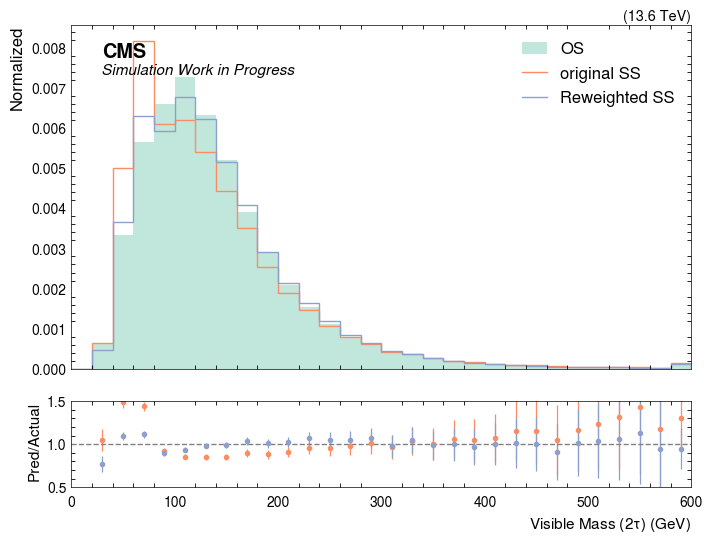

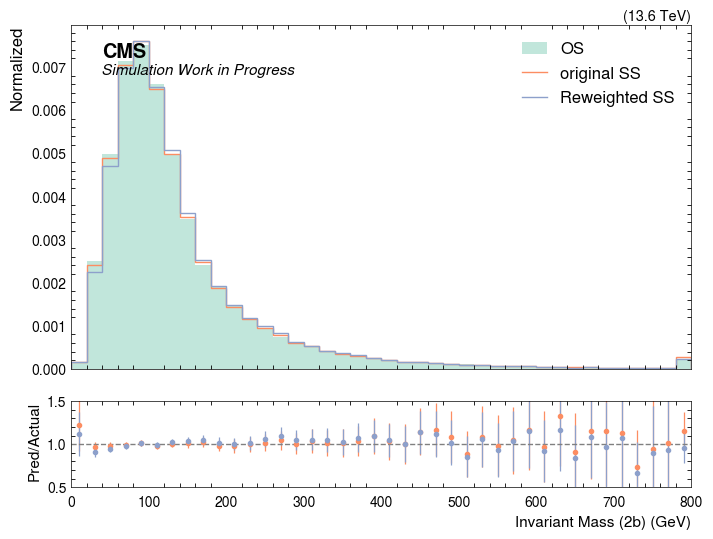

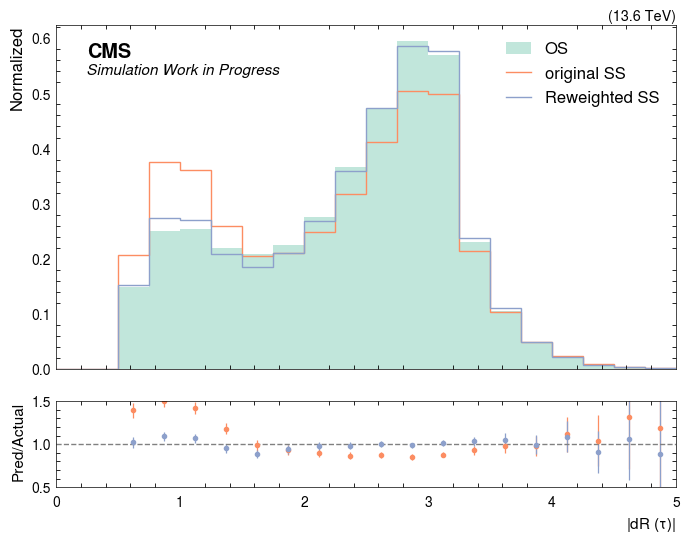

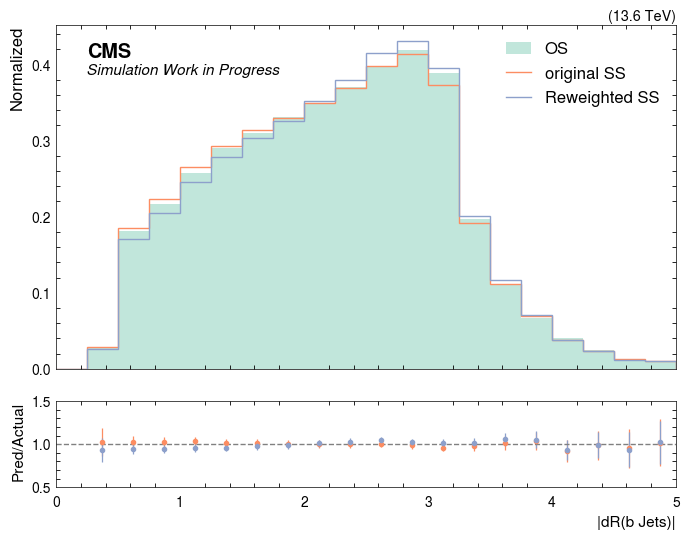

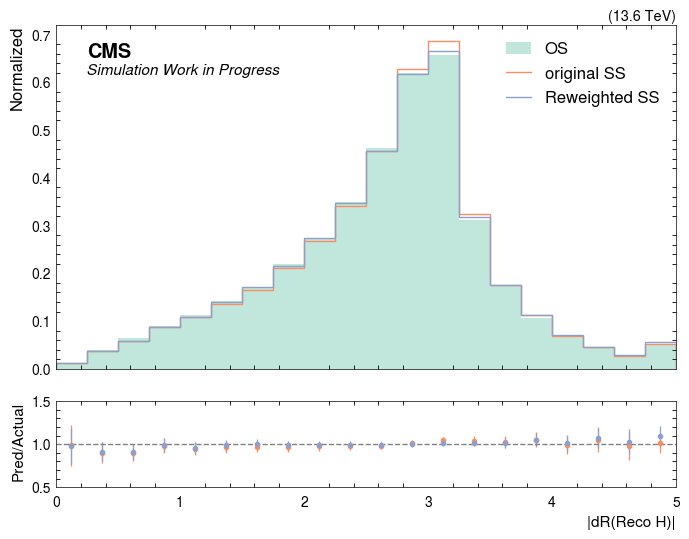

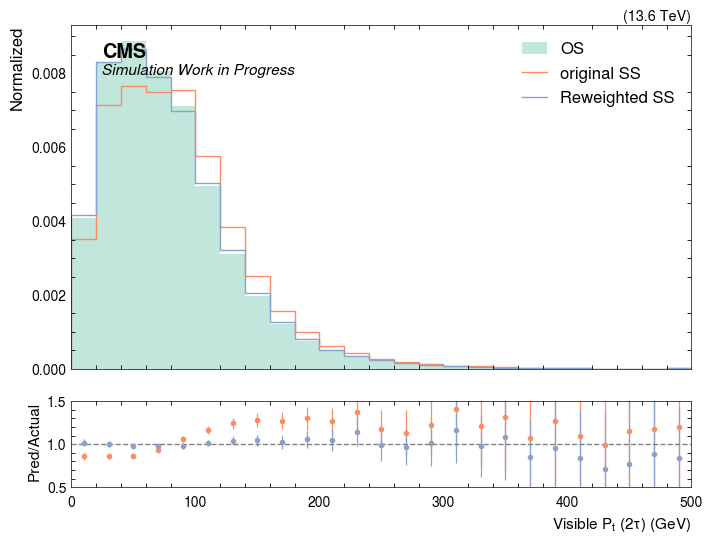

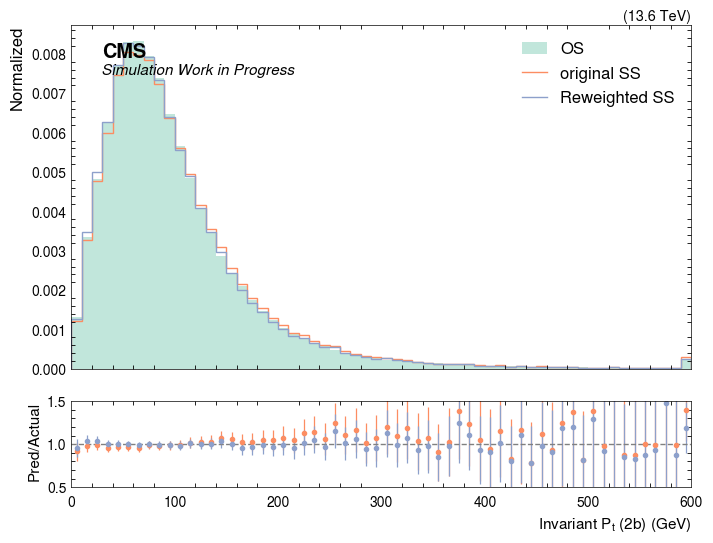

In [138]:
plot_rwgt_results(src_df, tar_df, total_1b_rwgt, is_train=False)